# Automatic Music Transcription
* Convert audio mp3 files to ascii gutar tabs

In [1]:
from __future__ import unicode_literals, print_function, division
from io import open
import unicodedata
import re
import random

import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F

import numpy as np
from torch.utils.data import TensorDataset, DataLoader, RandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
device

device(type='cuda')

### Preprocessing

In [3]:
# Load in the mp3 file, get the sample rate, and get the data
# from the file
#

import numpy as np
import matplotlib.pyplot as plt
import librosa

# Load in the mp3 file
y, sr = librosa.load('dataset/john-mayer/3_Why_Georgia.mp3')

In [4]:
# Get the data from the file
data = librosa.feature.mfcc(y=y, sr=sr)

In [5]:
librosa.version.version

'0.10.1'

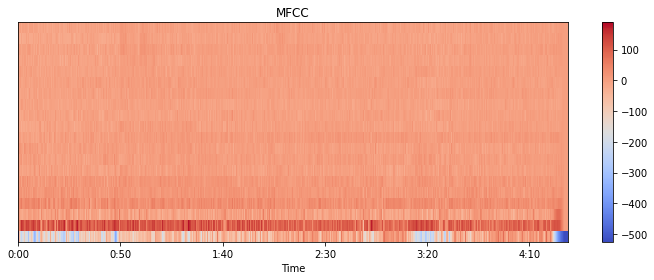

In [6]:
# Plot the data
plt.figure(figsize=(10, 4))
librosa.display.specshow(data, x_axis='time')
plt.colorbar()
plt.title('MFCC')
plt.tight_layout()
plt.show()

Wait, do we actually need to be able to convert back to audo? Hmm actually no we just need to be able to get the tab.  For now let's stick with mfcc and see what happens

Ok we have our input as a feature vector.  Now we need to get the tab output also in a vector format.  

TODO: Compression.  Try converting input audio samples to the latent space.

In [7]:
# install pyguitarpro
# !pip install pyguitarpro

In [8]:
# !pip install --upgrade attrs


In [9]:
import guitarpro

# Load in the gp5 file
song = guitarpro.parse('dataset/john-mayer/3_why-georgia.gp5')

In [10]:
notes = []

for track in song.tracks:
    for measure in track.measures:
        for voice in measure.voices:
            for beat in voice.beats:
                for note in beat.notes:
                    notes.append(note)


In [14]:
len(notes), notes[0]

(9564,
 Note(value=0, velocity=47, string=4, effect=<guitarpro.models.NoteEffect object at 0x7f1f87acae80>, durationPercent=1.0, swapAccidentals=False, type=<NoteType.dead: 3>))

In [25]:
token_note_format = 'instrument:note:string:fret'
token_rest_format = 'instrument:rest'

song.tempo, song.key

(98, <KeySignature.CMajor: (0, 0)>)

In [73]:
def tokenize_note_effect(note_effect):
    effect_tokens = []
    
    if note_effect.accentuatedNote:
        effect_tokens.append('nfx:accentuated')
        
    if note_effect.bend:
        effect_tokens.append(f'nfx:bend:{note_effect.bend.type}')
        
    if note_effect.ghostNote:
        effect_tokens.append('nfx:ghost')
        
    if note_effect.grace:
        effect_tokens.append(f'nfx:grace:{note_effect.grace.fret}:{note_effect.grace.duration}:{note_effect.grace.transition}')
        
    if note_effect.hammer:
        effect_tokens.append('nfx:hammer')
        
    if note_effect.harmonic:
        # Assuming harmonic.type exists or similar attributes to represent harmonic type
        effect_tokens.append(f'nfx:harmonic:{type(note_effect.harmonic).__name__}')
        
    if note_effect.heavyAccentuatedNote:
        effect_tokens.append('nfx:heavy_accentuated')
        
    if note_effect.leftHandFinger != 'open':
        effect_tokens.append(f'nfx:left_finger:{note_effect.leftHandFinger}')
        
    if note_effect.letRing:
        effect_tokens.append('nfx:let_ring')
        
    if note_effect.palmMute:
        effect_tokens.append('nfx:palm_mute')
        
    if note_effect.rightHandFinger != 'open':
        effect_tokens.append(f'nfx:right_finger:{note_effect.rightHandFinger}')
        
    if note_effect.slides:
        for slide in note_effect.slides:
            effect_tokens.append(f'nfx:slide:{slide}')
            
    if note_effect.staccato:
        effect_tokens.append('nfx:staccato')
        
    if note_effect.tremoloPicking:
        effect_tokens.append(f'nfx:tremolo:{note_effect.tremoloPicking.duration.value}')
        
    if note_effect.trill:
        effect_tokens.append(f'nfx:trill:{note_effect.trill.fret}:{note_effect.trill.duration.value}')
        
    if note_effect.vibrato:
        effect_tokens.append('nfx:vibrato')
        
    return effect_tokens


In [80]:

def tokenize_song(song):
    tokens = []
    
    # Start tokens
    tokens.append(f'artist:{song.artist}')
    tokens.append(f'downtune:{song.tracks[0].strings[0].value}')  # Assuming first track, first string for downtune info
    tokens.append(f'tempo:{song.tempo}')
    tokens.append('start')
    tokens.append('new_measure')

    for track in song.tracks:
        for measure in track.measures:
            for voice in measure.voices:
                for beat in voice.beats:
                    
                    if track.isPercussionTrack:
                        pass    # TODO Skip drums for now
                        # tokens.append(f'drums:note:{beat.notes[0].value}')  # Assuming one note per beat for drums
                    else:
                        # Note tokens for pitched instruments (guitar, bass, etc. not drums)
                        for note in beat.notes:
                            tokens.append(f'{track.name}:note:s{note.string}:f{note.value}')

                            if isinstance(note.effect, guitarpro.NoteEffect):  # This part is pseudo-code; adapt based on actual PyGuitarPro attributes
                                note_effect_token = tokenize_note_effect(note.effect)
                                tokens.append(f'nfx:{note_effect_token}')
                    
                    # Assuming 'wait' tokens are in terms of beats; adapt as needed
                    tokens.append(f'wait:{beat.duration.value}')

                    # Rest tokens
                    if beat.status == guitarpro.BeatStatus.rest:
                        tokens.append(f'{track.name}:note:rest')
                        
                    # Add any beat effects, note effects, tempo changes, etc.
                    # ... (this part depends on what effects you want to include)
    tokens.append('end')
    return tokens

# Load the song using PyGuitarPro (pseudo-code)
# song = guitarpro.parse('path/to/your/file.gp5')

# Tokenize the song
# tokenize_song(song)

# Print the tokens (or save them, etc.)
# print(tokens)


In [81]:
tokenize_song(song)

['artist:John Mayer',
 'downtune:64',
 'tempo:98',
 'start',
 'new_measure',
 'wait:4',
 'Guitar 1:note:rest',
 'Guitar 1:note:s4:f0',
 "nfx:['nfx:left_finger:Fingering.open', 'nfx:right_finger:Fingering.open']",
 'Guitar 1:note:s5:f0',
 "nfx:['nfx:left_finger:Fingering.open', 'nfx:right_finger:Fingering.open']",
 'Guitar 1:note:s6:f3',
 "nfx:['nfx:left_finger:Fingering.open', 'nfx:let_ring', 'nfx:right_finger:Fingering.open']",
 'wait:8',
 'Guitar 1:note:s2:f3',
 "nfx:['nfx:left_finger:Fingering.open', 'nfx:right_finger:Fingering.open']",
 'Guitar 1:note:s3:f0',
 "nfx:['nfx:hammer', 'nfx:left_finger:Fingering.open', 'nfx:right_finger:Fingering.open']",
 'wait:16',
 'Guitar 1:note:s3:f2',
 "nfx:['nfx:left_finger:Fingering.open', 'nfx:right_finger:Fingering.open']",
 'wait:16',
 'Guitar 1:note:s5:f0',
 "nfx:['nfx:left_finger:Fingering.open', 'nfx:right_finger:Fingering.open']",
 'Guitar 1:note:s6:f0',
 "nfx:['nfx:left_finger:Fingering.open', 'nfx:right_finger:Fingering.open']",
 'wait:1

In [79]:
print(tokenize_note_effect(notes[0].effect))

notes[0]

['nfx:left_finger:Fingering.open', 'nfx:right_finger:Fingering.open']


Note(value=0, velocity=47, string=4, effect=<guitarpro.models.NoteEffect object at 0x7f1f87acae80>, durationPercent=1.0, swapAccidentals=False, type=<NoteType.dead: 3>)